In [1]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import train_test_split, validation_curve, RandomizedSearchCV
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, roc_auc_score, RocCurveDisplay)
import matplotlib.pyplot as plt
import DecompensationImputed

## Random Forest (all features, no Lasso selection)

In [2]:
# Load all features (no Lasso filtering)
X_all, y_all, groups_all = DecompensationImputed.load_data(
    sample_size=20000, icu_vitals=True,
    top_n_labs=230, top_n_drugs=954, top_n_procedures=55,
    step_hours=48
)

# Patient-level split
unique_subjects = groups_all.unique()
np.random.seed(42)
np.random.shuffle(unique_subjects)
split = int(0.8 * len(unique_subjects))
train_subjects = set(unique_subjects[:split])
train_mask = groups_all.isin(train_subjects)

X_train_all, X_test_all = X_all[train_mask], X_all[~train_mask]
y_train_all, y_test_all = y_all[train_mask], y_all[~train_mask]

scaler_all = StandardScaler()
X_train_all_scaled = scaler_all.fit_transform(X_train_all)
X_test_all_scaled = scaler_all.transform(X_test_all)

print(f"All features: {X_all.shape[1]}")
print(f"Train: {X_train_all.shape} ({y_train_all.mean():.4%} positive)")
print(f"Test:  {X_test_all.shape} ({y_test_all.mean():.4%} positive)")

Sampled 18750 admissions (8750 deaths, 10000 survived)
Avg length of stay: 237.6 hours (9.9 days)
Generated 83763 windows from 18750 admissions (4.5 windows/admission)
Positive windows: 4373 (5.2207%)
Cached to: decomp_rolling_n20000_v1_l230_d954_p55_o48_pred24_s48
Returning 83763 windows with 648 features. y distribution:
y
0    0.947793
1    0.052207
Name: proportion, dtype: float64
All features: 648
Train: (67194, 648) (5.2311% positive)
Test:  (16569, 648) (5.1783% positive)


Random Forest (all 648 features)
ROC-AUC: 0.800  TPR: 0.583  FPR: 0.171  Precision: 0.157
              precision    recall  f1-score   support

    Survived       0.97      0.83      0.90     15711
        Died       0.16      0.58      0.25       858

    accuracy                           0.82     16569
   macro avg       0.56      0.71      0.57     16569
weighted avg       0.93      0.82      0.86     16569



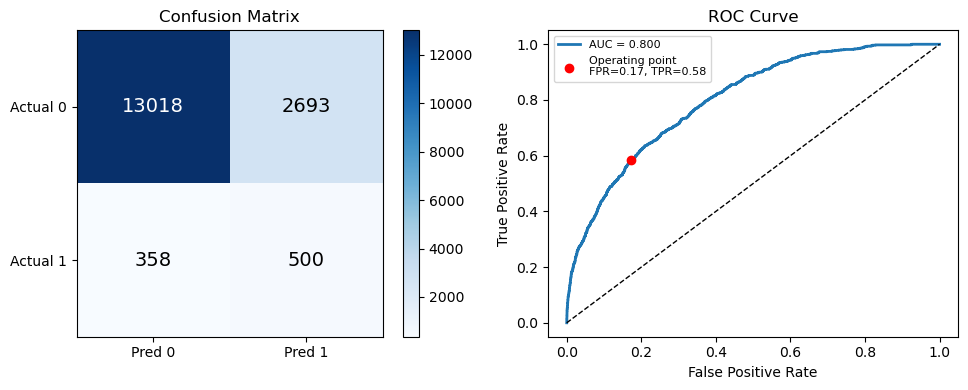

In [6]:
rf_all = RandomForestClassifier(
    n_estimators=100, max_depth=10, max_features="sqrt",
    min_samples_leaf=5, class_weight="balanced",
    random_state=42, n_jobs=-1
).fit(X_train_all_scaled, y_train_all)

y_pred = rf_all.predict(X_test_all_scaled)
y_proba = rf_all.predict_proba(X_test_all_scaled)[:, 1]

cm = confusion_matrix(y_test_all, y_pred)
tn, fp, fn, tp = cm.ravel()
tpr = tp / (tp + fn); fpr = fp / (fp + tn); ppv = tp / (tp + fp)
print(f"Random Forest (all {X_all.shape[1]} features)")
print(f"ROC-AUC: {roc_auc_score(y_test_all, y_proba):.3f}  TPR: {tpr:.3f}  FPR: {fpr:.3f}  Precision: {ppv:.3f}")
print(classification_report(y_test_all, y_pred, target_names=['Survived', 'Died']))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Pred 0', 'Pred 1']); axes[0].set_yticklabels(['Actual 0', 'Actual 1'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)
axes[0].set_title('Confusion Matrix'); plt.colorbar(im, ax=axes[0])

fpr_curve, tpr_curve, _ = roc_curve(y_test_all, y_proba)
auc = roc_auc_score(y_test_all, y_proba)
axes[1].plot(fpr_curve, tpr_curve, lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].scatter([fpr], [tpr], color='red', zorder=5, label=f'Operating point\nFPR={fpr:.2f}, TPR={tpr:.2f}')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

In [50]:
# Load Lasso-selected features from logistic regression notebook
keep = pd.read_csv('results/lasso_selected_features.csv', header=None)[0].tolist()
print(f"Loading with {len(keep)} Lasso-selected features")

X, y, groups = DecompensationImputed.load_data(
    sample_size=100000, icu_vitals=True,
    top_n_labs=230, top_n_drugs=954, top_n_procedures=55,
    step_hours=48, keep_features=keep
)
X = X[[c for c in keep if c in X.columns]]
print(f"Final feature matrix: {X.shape}")

Loading with 199 Lasso-selected features
Loading from cache: decomp_rolling_n100000_v1_l230_d954_p55_o48_pred24_s48_kf199
Returning 205098 windows with 226 features. y distribution:
y
0    0.978678
1    0.021322
Name: proportion, dtype: float64
Final feature matrix: (205098, 199)


In [51]:
# 80/20 patient-level split (no data from the same patient in both train and test)
unique_subjects = groups.unique()
np.random.seed(42)
np.random.shuffle(unique_subjects)
split = int(0.8 * len(unique_subjects))
train_subjects = set(unique_subjects[:split])
train_mask = groups.isin(train_subjects)

X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

print(f"Train: {X_train.shape} ({y_train.mean():.4%} positive)")
print(f"Test:  {X_test.shape} ({y_test.mean():.4%} positive)")

Train: (164223, 199) (2.1325% positive)
Test:  (40875, 199) (2.1309% positive)


In [52]:
print(X.shape)
X.head(20)

(205098, 199)


,anchor_age,vital_heart_rate,vital_respiratory_rate,lab_absolute_eosinophil_count,lab_alkaline_phosphatase,lab_alveolar-arterial_gradient,"lab_amylase,_ascites",lab_anion_gap,lab_base_excess,lab_basophils,...,procedure_9915,procedure_9925,admission_type_ELECTIVE,admission_type_EW EMER.,admission_type_SURGICAL SAME DAY ADMISSION,admission_location_INTERNAL TRANSFER TO OR FROM PSYCH,admission_location_PHYSICIAN REFERRAL,admission_location_TRANSFER FROM SKILLED NURSING FACILITY,insurance_Other,race_BLACK
0,91,86.571429,19.691489,0.010,56.000000,488.0,32.75,19.000000,0.000000,0.000000,...,0.0,0.0,0,1,0,0,0,0,0,0
1,91,86.571429,19.691489,0.010,56.000000,488.0,32.75,16.875000,0.000000,0.000000,...,0.0,0.0,0,1,0,0,0,0,0,0
2,91,86.571429,19.691489,0.015,56.000000,488.0,32.75,16.333333,0.000000,0.000000,...,0.0,0.0,0,1,0,0,0,0,0,0
3,91,86.571429,19.691489,0.015,56.000000,488.0,32.75,16.071429,0.000000,0.000000,...,0.0,0.0,0,1,0,0,0,0,0,0
4,91,111.833333,21.583333,0.015,82.666667,488.0,32.75,15.294118,0.166667,0.000000,...,0.0,0.0,0,1,0,0,0,0,0,0
5,91,73.470588,29.147059,0.080,301.000000,488.0,32.75,19.600000,-4.000000,0.250000,...,0.0,0.0,0,1,0,0,0,0,0,1
6,91,74.690476,28.809524,0.080,277.000000,488.0,32.75,18.857143,-4.000000,0.250000,...,0.0,0.0,0,1,0,0,0,0,0,1
7,91,74.690476,28.809524,0.080,277.600000,488.0,32.75,18.500000,-4.000000,0.250000,...,0.0,0.0,0,1,0,0,0,0,0,1
8,91,76.187500,29.520833,0.080,265.000000,488.0,32.75,19.526316,-3.000000,0.300000,...,0.0,0.0,0,1,0,0,0,0,0,1
9,91,83.291667,32.000000,0.080,265.000000,488.0,32.75,20.173913,-3.000000,0.300000,...,0.0,0.0,0,1,0,0,0,0,0,1


In [53]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## Decision Tree (validation curve over max_depth)

In [54]:
param_range =  [3,5,7,10,15,20,30,50,100,500]
train_scores, val_scores = validation_curve(
    DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    X_train_scaled, y_train,
    param_name="max_depth",
    param_range=param_range,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
mean_val = val_scores.mean(axis=1)
best_depth = param_range[np.argmax(mean_val)]
print("best max_depth:", best_depth)

best max_depth: 7


In [55]:
decision_tree_model = DecisionTreeClassifier(max_depth=best_depth, class_weight="balanced", random_state=42).fit(X_train_scaled, y_train)

Confusion matrix:
                Pred 0   Pred 1
  Actual 0       29834    10170   (specificity 0.746)
  Actual 1         215      656   (sensitivity 0.753)

TPR (sensitivity):  0.753
FPR (fall-out):     0.254
Precision:          0.061
ROC-AUC:            0.805

              precision    recall  f1-score   support

    Survived       0.99      0.75      0.85     40004
        Died       0.06      0.75      0.11       871

    accuracy                           0.75     40875
   macro avg       0.53      0.75      0.48     40875
weighted avg       0.97      0.75      0.84     40875



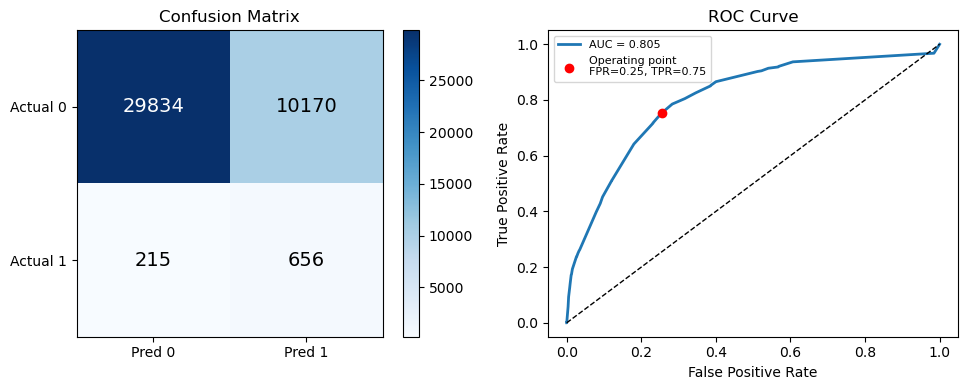

In [56]:
y_pred  = decision_tree_model.predict(X_test_scaled)
y_proba = decision_tree_model.predict_proba(X_test_scaled)[:, 1]

# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
tpr = tp / (tp + fn)   # sensitivity / recall
fpr = fp / (fp + tn)   # fall-out
tnr = tn / (tn + fp)   # specificity
ppv = tp / (tp + fp)   # precision

print("Confusion matrix:")
print(f"  {'':12s}  Pred 0   Pred 1")
print(f"  {'Actual 0':12s}  {tn:>6}   {fp:>6}   (specificity {tnr:.3f})")
print(f"  {'Actual 1':12s}  {fn:>6}   {tp:>6}   (sensitivity {tpr:.3f})")
print()
print(f"TPR (sensitivity):  {tpr:.3f}")
print(f"FPR (fall-out):     {fpr:.3f}")
print(f"Precision:          {ppv:.3f}")
print(f"ROC-AUC:            {roc_auc_score(y_test, y_proba):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=['Survived', 'Died']))

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Confusion matrix heatmap
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Pred 0', 'Pred 1'])
axes[0].set_yticklabels(['Actual 0', 'Actual 1'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)
axes[0].set_title('Confusion Matrix')
plt.colorbar(im, ax=axes[0])

# ROC curve
fpr_curve, tpr_curve, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr_curve, tpr_curve, lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].scatter([fpr], [tpr], color='red', zorder=5, label=f'Operating point\nFPR={fpr:.2f}, TPR={tpr:.2f}')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve'); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Decision Tree (unbounded depth)

In [57]:
decision_tree_max_depth = DecisionTreeClassifier(max_depth=None, random_state=42).fit(X_train_scaled, y_train)

Confusion matrix:
                Pred 0   Pred 1
  Actual 0       38231     1773   (specificity 0.956)
  Actual 1         675      196   (sensitivity 0.225)

TPR (sensitivity):  0.225
FPR (fall-out):     0.044
Precision:          0.100
ROC-AUC:            0.596

              precision    recall  f1-score   support

    Survived       0.98      0.96      0.97     40004
        Died       0.10      0.23      0.14       871

    accuracy                           0.94     40875
   macro avg       0.54      0.59      0.55     40875
weighted avg       0.96      0.94      0.95     40875



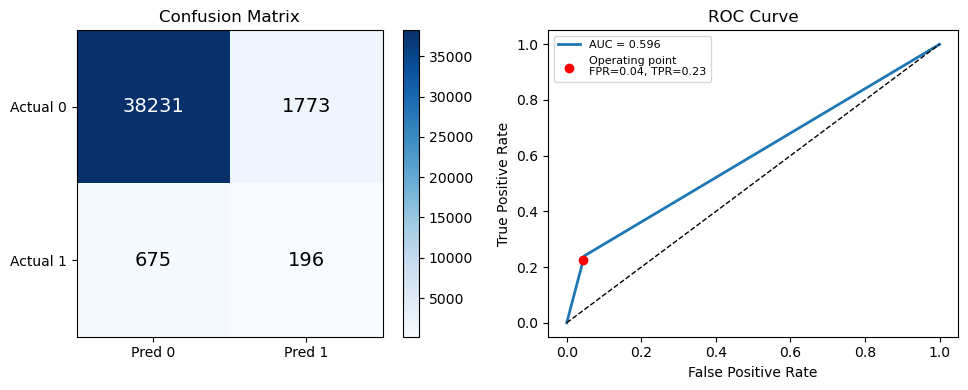

In [58]:
y_pred  = decision_tree_max_depth.predict(X_test_scaled)
y_proba = decision_tree_max_depth.predict_proba(X_test_scaled)[:, 1]

# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
tpr = tp / (tp + fn)   # sensitivity / recall
fpr = fp / (fp + tn)   # fall-out
tnr = tn / (tn + fp)   # specificity
ppv = tp / (tp + fp)   # precision

print("Confusion matrix:")
print(f"  {'':12s}  Pred 0   Pred 1")
print(f"  {'Actual 0':12s}  {tn:>6}   {fp:>6}   (specificity {tnr:.3f})")
print(f"  {'Actual 1':12s}  {fn:>6}   {tp:>6}   (sensitivity {tpr:.3f})")
print()
print(f"TPR (sensitivity):  {tpr:.3f}")
print(f"FPR (fall-out):     {fpr:.3f}")
print(f"Precision:          {ppv:.3f}")
print(f"ROC-AUC:            {roc_auc_score(y_test, y_proba):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=['Survived', 'Died']))

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Confusion matrix heatmap
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Pred 0', 'Pred 1'])
axes[0].set_yticklabels(['Actual 0', 'Actual 1'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)
axes[0].set_title('Confusion Matrix')
plt.colorbar(im, ax=axes[0])

# ROC curve
fpr_curve, tpr_curve, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr_curve, tpr_curve, lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].scatter([fpr], [tpr], color='red', zorder=5, label=f'Operating point\nFPR={fpr:.2f}, TPR={tpr:.2f}')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve'); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Random Forest

In [59]:
random_forest = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10,
    max_features="sqrt",
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    verbose=2,
    n_jobs=-1).fit(X_train_scaled, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.


building tree 3 of 100
building tree 9 of 100
building tree 10 of 100
building tree 12 of 100
building tree 4 of 100
building tree 1 of 100
building tree 11 of 100
building tree 7 of 100
building tree 2 of 100
building tree 6 of 100
building tree 8 of 100
building tree 5 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100


[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    0.7s


building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74 of 100
building tree 75 of 100
building tree 76 of 100
building tree 77 of 100
building tree 78

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    3.6s finished


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished


Confusion matrix:
                Pred 0   Pred 1
  Actual 0       33824     6180   (specificity 0.846)
  Actual 1         267      604   (sensitivity 0.693)

TPR (sensitivity):  0.693
FPR (fall-out):     0.154
Precision:          0.089
ROC-AUC:            0.875

              precision    recall  f1-score   support

    Survived       0.99      0.85      0.91     40004
        Died       0.09      0.69      0.16       871

    accuracy                           0.84     40875
   macro avg       0.54      0.77      0.54     40875
weighted avg       0.97      0.84      0.90     40875



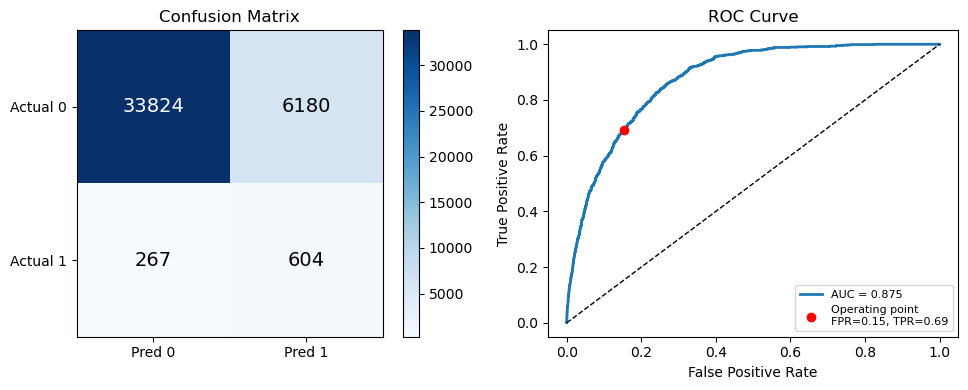

In [60]:
y_pred  = random_forest.predict(X_test_scaled)
y_proba = random_forest.predict_proba(X_test_scaled)[:, 1]

# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
tpr = tp / (tp + fn)   # sensitivity / recall
fpr = fp / (fp + tn)   # fall-out
tnr = tn / (tn + fp)   # specificity
ppv = tp / (tp + fp)   # precision

print("Confusion matrix:")
print(f"  {'':12s}  Pred 0   Pred 1")
print(f"  {'Actual 0':12s}  {tn:>6}   {fp:>6}   (specificity {tnr:.3f})")
print(f"  {'Actual 1':12s}  {fn:>6}   {tp:>6}   (sensitivity {tpr:.3f})")
print()
print(f"TPR (sensitivity):  {tpr:.3f}")
print(f"FPR (fall-out):     {fpr:.3f}")
print(f"Precision:          {ppv:.3f}")
print(f"ROC-AUC:            {roc_auc_score(y_test, y_proba):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=['Survived', 'Died']))

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Confusion matrix heatmap
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Pred 0', 'Pred 1'])
axes[0].set_yticklabels(['Actual 0', 'Actual 1'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)
axes[0].set_title('Confusion Matrix')
plt.colorbar(im, ax=axes[0])

# ROC curve
fpr_curve, tpr_curve, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr_curve, tpr_curve, lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].scatter([fpr], [tpr], color='red', zorder=5, label=f'Operating point\nFPR={fpr:.2f}, TPR={tpr:.2f}')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve'); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## AdaBoost

In [32]:
adaboost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3, class_weight="balanced"),
    n_estimators=200,
    learning_rate=0.1,
    random_state=42,
)
adaboost.fit(X_train_scaled, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.","DecisionTreeC..., max_depth=3)"
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",200
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None


Confusion matrix:
                Pred 0   Pred 1
  Actual 0        6295     2418   (specificity 0.722)
  Actual 1         228      264   (sensitivity 0.537)

TPR (sensitivity):  0.537
FPR (fall-out):     0.278
Precision:          0.098
ROC-AUC:            0.630

              precision    recall  f1-score   support

    Survived       0.97      0.72      0.83      8713
        Died       0.10      0.54      0.17       492

    accuracy                           0.71      9205
   macro avg       0.53      0.63      0.50      9205
weighted avg       0.92      0.71      0.79      9205



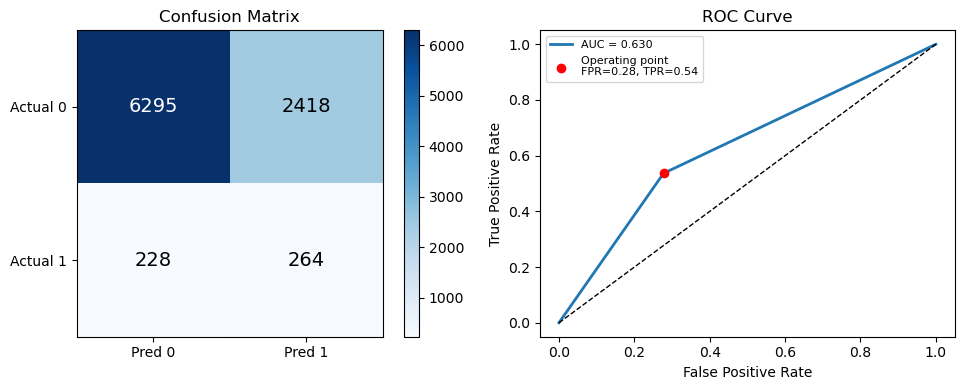

In [33]:
y_pred  = adaboost.predict(X_test_scaled)
y_proba = adaboost.predict_proba(X_test_scaled)[:, 1]

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
tpr = tp / (tp + fn)
fpr = fp / (fp + tn)
tnr = tn / (tn + fp)
ppv = tp / (tp + fp)

print("Confusion matrix:")
print(f"  {'':12s}  Pred 0   Pred 1")
print(f"  {'Actual 0':12s}  {tn:>6}   {fp:>6}   (specificity {tnr:.3f})")
print(f"  {'Actual 1':12s}  {fn:>6}   {tp:>6}   (sensitivity {tpr:.3f})")
print()
print(f"TPR (sensitivity):  {tpr:.3f}")
print(f"FPR (fall-out):     {fpr:.3f}")
print(f"Precision:          {ppv:.3f}")
print(f"ROC-AUC:            {roc_auc_score(y_test, y_proba):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=['Survived', 'Died']))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Pred 0', 'Pred 1'])
axes[0].set_yticklabels(['Actual 0', 'Actual 1'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)
axes[0].set_title('Confusion Matrix')
plt.colorbar(im, ax=axes[0])

fpr_curve, tpr_curve, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr_curve, tpr_curve, lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].scatter([fpr], [tpr], color='red', zorder=5, label=f'Operating point\nFPR={fpr:.2f}, TPR={tpr:.2f}')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve'); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## RandomizedSearchCV

In [17]:
clf = RandomForestClassifier(n_jobs=-1, random_state=42)

param_dist = {
    "n_estimators": [50, 100, 200, 500, 1000],
    "max_depth": [3, 5, 20, 30, None],
    "max_features": ["sqrt", 0.2, 0.5],
    "min_samples_leaf": [1, 5, 10, 20],
    "min_samples_split": [2, 10, 20, 50],
    "bootstrap": [True],
}

rs = RandomizedSearchCV(clf, param_dist, n_iter=100, cv=5, scoring="roc_auc", n_jobs=-1, random_state=42)
rs.fit(X_train, y_train)
print(rs.best_params_)

Exception ignored in: <Finalize object, dead>
Traceback (most recent call last):
  File "/nix/store/82d4idzilks59f2waanikzv3an5cn8q0-python3-3.13.12-env/lib/python3.13/multiprocessing/util.py", line 276, in __call__
    def __call__(self, wr=None,
KeyboardInterrupt: 


KeyboardInterrupt: 